# Getting started
This is a working notebook for generating data analysis capsules for the FutureHouse Evals team. You'll find basic instructions for how to use this notebook below.

If you are not familiar with Colab Notebooks, please visit the welcome notebook at: https://colab.research.google.com/notebooks/intro.ipynb. In short, they function similarly to Jupyter Notebooks, but are more shareable for our purpose.

You may write code in either Python or R. The default is Python, but you may use R on a cell-by-cell basis using the code example below, or in the whole notebook by changing the Runtime in the tab at the top of the notebook.

## Basic instructions
This notebook has been created for your specific use, so you should work directly in it.

We ask that you are as verbose as possible in your descriptions of various steps, as well as in your in-line code comments. This includes reasoning about the steps taken and decisions made for using various tools. Feel free to make liberal use of both in-line comments and text cells for this.

It is also helpful if you are liberal in your use of code cells, e.g. using one cell per function, rather than including too much code together in a single cell.

As always, if you have any questions do not hesitate to reach out to Jon via Slack or email (jon@futurehouse.org)



---

## If using R, read below. Otherwise skip to [Analysis](#scrollTo=vA60UJdshKhw)


If you will be using R in some part of your analysis, run the cell below first. You can then include `%%R` at the top of any cell to run it as R code rather than Python.

If your entire analysis will be R, you can change the notebook runtime in the Runtime tab above.

In [ ]:
## loading rmagic to enable R
## to use R in a cell, put %%R at the top
%load_ext rpy2.ipython

In [ ]:
## Example of R code cell

%%R      ## put this at the top of a cell to run R code inside it
x <- 42
print(x)

[1] 42




---



# Analysis

### Package loading

In [ ]:
## Please install and load all external packages and libraries below this cell.

In [1]:
# Install packages.
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

# Install DESeq2 to import DESeq objects.
BiocManager::install("DESeq2")

# Install clusterProfiler for KEGG enrichment analysis.
BiocManager::install("clusterProfiler")

# Library packages.
library(tidyverse)
library(clusterProfiler)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.2 (2024-10-31)

Installing package(s) 'BiocVersion', 'DESeq2'

also installing the dependencies ‘formatR’, ‘UCSC.utils’, ‘GenomeInfoDbData’, ‘zlibbioc’, ‘abind’, ‘SparseArray’, ‘lambda.r’, ‘futile.options’, ‘GenomeInfoDb’, ‘XVector’, ‘S4Arrays’, ‘DelayedArray’, ‘futile.logger’, ‘snow’, ‘BH’, ‘S4Vectors’, ‘IRanges’, ‘GenomicRanges’, ‘SummarizedExperiment’, ‘BiocGenerics’, ‘Biobase’, ‘BiocParallel’, ‘matrixStats’, ‘locfit’, ‘MatrixGenerics’, ‘RcppArmadillo’


Old packages: 'curl'

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstud

### Data loading

In [ ]:
## Please load any external input data or define locations for local input data below this cell.

In [2]:
# Import data for DESeq object of P. aeruginosa from two different media types, minimal glucose media without iron (GluFe) and succinate (Succ) differential expression profiles relative to a reference medium which is minimal glucose with iron (GluFePlus). Differential expression analysis was performed in previous capsule.
res_GluFevsGluFePlus <- readRDS("res_GluFevsGluFePlus.rds")
res_SuccvsGluFePlus <- readRDS("res_SuccvsGluFePlus.rds")


### Analysis code

In [ ]:
## Begin analysis code below this cell.

In [3]:
## Prepare data to input into KEGG enrichment function (media).
# GluMinusFe
# Get upregulated genes.
DE_genes_PlusvsMinus_up <- res_GluFevsGluFePlus %>%
  as.data.frame %>%
    dplyr::select(log2FoldChange, padj) %>%
    filter(log2FoldChange > 1.5) %>%
      rownames_to_column(var = "GeneID")

# Get downregulated genes.
DE_genes_PlusvsMinus_dn <- res_GluFevsGluFePlus  %>%
  as.data.frame %>%
    dplyr::select(log2FoldChange, padj) %>%
    filter(log2FoldChange < -1.5) %>%
      rownames_to_column(var = "GeneID")

# Succinate
# Get upregulated genes.
DE_genes_PlusvsSucc_up <- res_SuccvsGluFePlus %>%
  as.data.frame %>%
    dplyr::select(log2FoldChange, padj) %>%
    filter(log2FoldChange > 1.5) %>%
      rownames_to_column(var = "GeneID")

# Get downregulated genes.
DE_genes_PlusvsSucc_dn <- res_SuccvsGluFePlus  %>%
  as.data.frame %>%
    dplyr::select(log2FoldChange, padj) %>%
    filter(log2FoldChange < -1.5) %>%
      rownames_to_column(var = "GeneID")

Loading required package: DESeq2

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:clus

In [4]:
## Perform KEGG enrichment analysis.
# GluMinusFe
kegg_result_PlusvsMinus_up <- enrichKEGG(gene = DE_genes_PlusvsMinus_up$GeneID,
                                 organism = "pau",  # Pseudomonas aeruginosa UCBPP-PA14 organism code
                                 pvalueCutoff = 0.05,
                                 qvalueCutoff = 0.05)

kegg_result_PlusvsMinus_dn <- enrichKEGG(gene = DE_genes_PlusvsMinus_dn$GeneID,
                                 organism = "pau",  # Pseudomonas aeruginosa UCBPP-PA14 organism code
                                 pvalueCutoff = 0.05,
                                 qvalueCutoff = 0.05)

# Succinate
kegg_result_PlusvsSucc_up <- enrichKEGG(gene = DE_genes_PlusvsSucc_up$GeneID,
                                 organism = "pau",  # Pseudomonas aeruginosa UCBPP-PA14 organism code
                                 pvalueCutoff = 0.05,
                                 qvalueCutoff = 0.05)

kegg_result_PlusvsSucc_dn <- enrichKEGG(gene = DE_genes_PlusvsSucc_dn$GeneID,
                                 organism = "pau",  # Pseudomonas aeruginosa UCBPP-PA14 organism code
                                 pvalueCutoff = 0.05,
                                 qvalueCutoff = 0.05)

Reading KEGG annotation online: "https://rest.kegg.jp/link/pau/pathway"...

Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/pau"...



In [5]:
## Tidy up date for downstream visualization.
# Add unique identifiers to two columns in each data frame
KEGG_PlusvsMinus_up <- kegg_result_PlusvsMinus_up %>% as.data.frame %>% mutate(Media = "FeMinus", Regulation = "Up")
KEGG_PlusvsMinus_dn <- kegg_result_PlusvsMinus_dn %>% as.data.frame %>% mutate(Media = "FeMinus", Regulation = "Dn")

KEGG_PlusvsSucc_up <- kegg_result_PlusvsSucc_up %>% as.data.frame %>% mutate(Media = "Succ", Regulation = "Up")
KEGG_PlusvsSucc_dn <- kegg_result_PlusvsSucc_dn %>% as.data.frame %>% mutate(Media = "Succ", Regulation = "Dn")

# Merge different datasets into a single dataframe
Media_KEGG <- rbind(KEGG_PlusvsMinus_up, KEGG_PlusvsMinus_dn, KEGG_PlusvsSucc_up, KEGG_PlusvsSucc_dn)

# Remove extra character string from Description
Media_KEGG <- Media_KEGG %>%
  mutate(Description = sub(" - Pseudomonas aeruginosa UCBPP-PA14", "", Description))

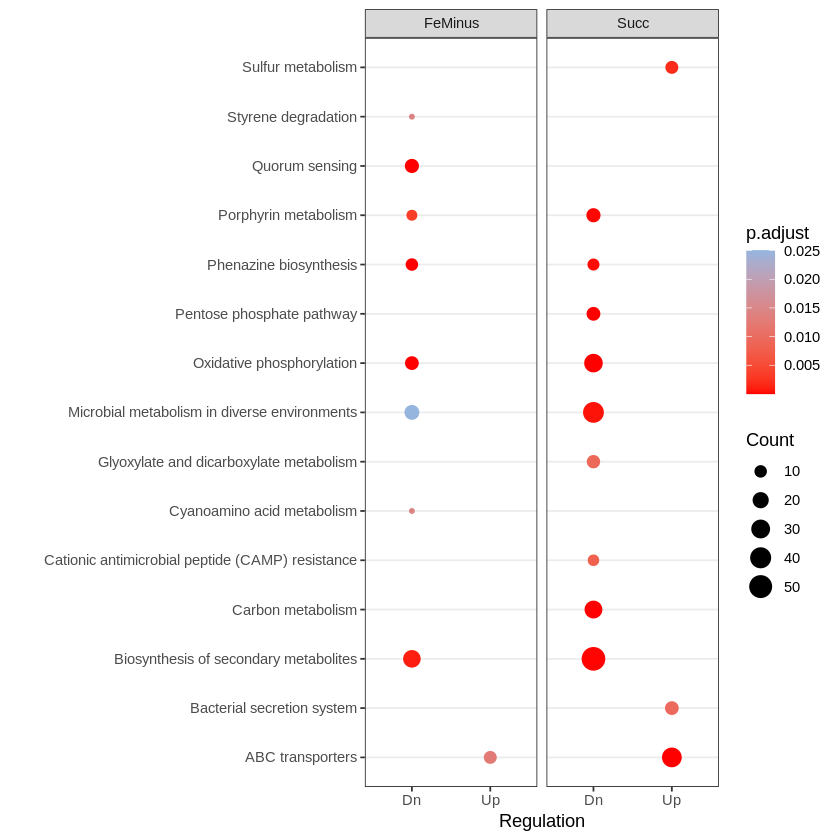

In [6]:
## Visualize functional enrichment analysis.
# Plot dotplot
ggplot(Media_KEGG, aes(x = Regulation, y = Description, color = `p.adjust`, size = Count)) +
  geom_point() +
  scale_color_gradient(low = "red", high = "#95B5DF") +
  theme_bw() +
  ylab("") +
  facet_wrap(~Media) +
  theme(
#    panel.grid.major.y = element_line(linetype = "dashed", color = "gray"),
    panel.grid.major.y = element_line(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank())

# By visually inspecting the results, it is clear that the alterations in expression are not only strain-dependent, but environment-dependent as well. This suggests that the molecular mechanisms in which bacteria can divide labor differ under varied conditions.